In [2]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.1 MB/s eta 0:00:00


In [3]:
from faker import Faker

In [4]:
fake = Faker()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = []

for i in range(100000):
    age = np.random.randint(18, 71)
    gender = np.random.choice(["Male", "Female"])
    tenure = np.random.randint(0, 11)
    balance = round(np.random.uniform(0, 200000), 2)
    credit_score = np.random.randint(300, 901)
    salary = round(np.random.uniform(10000, 150000), 2)
    products = np.random.randint(1, 5)
    active = np.random.choice(["Yes", "No"])
    churn = 1 if (balance < 50000 and active == "No") else 0

    data.append([
        i+1, age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])

In [7]:
df = pd.DataFrame(data, columns=[
    "Customer_ID", "Age", "Gender", "Tenure", "Balance",
    "CreditScore", "EstimatedSalary", "NumOfProducts",
    "IsActiveMember", "Churn"
])


In [8]:
df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,39,Female,9,94509.90,561,136807.68,1,Yes,0
1,2,26,Female,3,185482.79,581,71784.23,2,No,0
2,3,30,Female,6,71501.92,587,32531.25,1,No,0
3,4,21,Male,4,87392.49,551,140253.64,3,Yes,0
4,5,21,Female,8,63059.79,530,34933.17,3,Yes,0


In [9]:
print(df.isnull().sum())
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["IsActiveMember"] = df["IsActiveMember"].map({"Yes": 1, "No": 0})

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Customer_ID      100000 non-null  int64  
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  int64  
 3   Tenure           100000 non-null  int64  
 4   Balance          100000 non-null  float64
 5   CreditScore      100000 non-null  int64  
 6   EstimatedSalary  100000 non-null  float64
 7   NumOfProducts    100000 non-null  int64  
 8   IsActiveMember   100000 non-null  int64  
 9   Churn            100000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 7.6 MB


In [11]:
print(df.describe())
print("Mean:\n", df.mean())
print("Median:\n", df.median())
print("Standard Deviation:\n", df.std())

         Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      44.022560       0.498110       4.992400   
std     28867.657797      15.304228       0.499999       3.160019   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      44.000000       0.000000       5.000000   
75%     75000.250000      57.000000       1.000000       8.000000   
max    100000.000000      70.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000  100000.000000   
mean   100204.960391     600.144140     80042.643103       2.499030   
std     57693.118281     173.491732     40422.374636       1.118075   
min         2.450000     300.000000     10001.270000       1.000000   
25%     50430.510000   

In [12]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)


Churn
0    87481
1    12519
Name: count, dtype: int64
Churn
0    87.481
1    12.519
Name: proportion, dtype: float64


In [13]:
print(pd.crosstab(df["Gender"], df["Churn"]))
print(pd.crosstab(df["IsActiveMember"], df["Churn"]))
print(pd.crosstab(df["NumOfProducts"], df["Churn"]))

Churn       0     1
Gender             
0       43869  6320
1       43612  6199
Churn               0      1
IsActiveMember              
0               37817  12519
1               49664      0
Churn              0     1
NumOfProducts             
1              21900  3143
2              21869  3103
3              21845  3179
4              21867  3094


In [14]:
corr = df.corr()
print(corr)

                 Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID         1.000000 -0.003038  0.002404 -0.001789  0.000578   
Age                -0.003038  1.000000 -0.002403  0.003880 -0.005442   
Gender              0.002404 -0.002403  1.000000 -0.004604 -0.003057   
Tenure             -0.001789  0.003880 -0.004604  1.000000  0.001164   
Balance             0.000578 -0.005442 -0.003057  0.001164  1.000000   
CreditScore         0.001279 -0.009056 -0.002121  0.001231  0.002141   
EstimatedSalary    -0.000140 -0.000082  0.001641 -0.003544  0.003181   
NumOfProducts       0.001509 -0.000428  0.001464  0.002143  0.003265   
IsActiveMember      0.000057 -0.003147  0.000875  0.001959 -0.002282   
Churn              -0.001701  0.008487 -0.002226 -0.004359 -0.493373   

                 CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  \
Customer_ID         0.001279        -0.000140       0.001509        0.000057   
Age                -0.009056        -0.000082  

BAR CHART

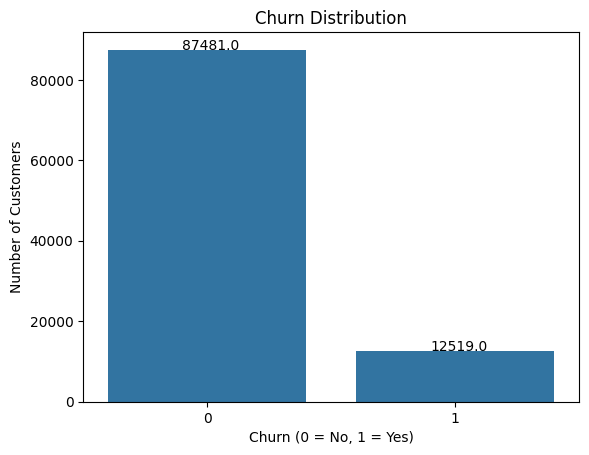

In [15]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
for p in plt.gca().patches:
    plt.gca().annotate(p.get_height(),
                       (p.get_x()+0.3, p.get_height()+100))

plt.show()

PIE CHART

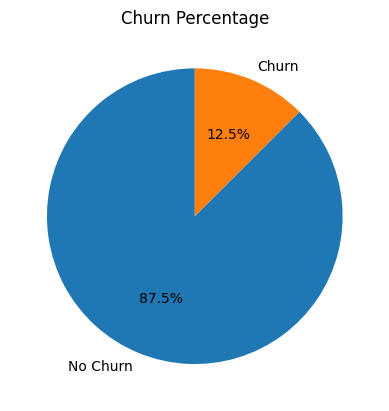

In [16]:
df["Churn"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["No Churn", "Churn"],
    startangle=90
)
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

HISTOGRAM

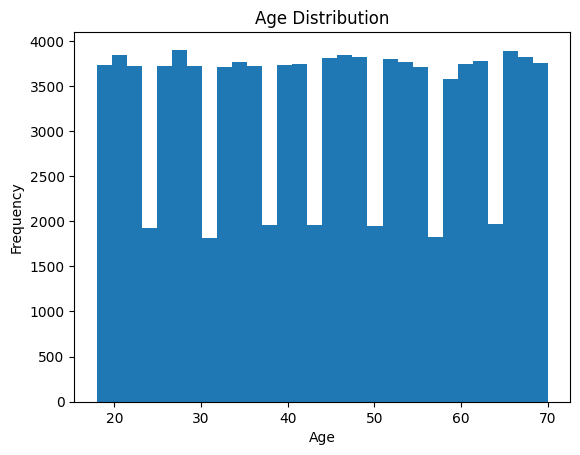

In [17]:

plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


SCATTER PLOT

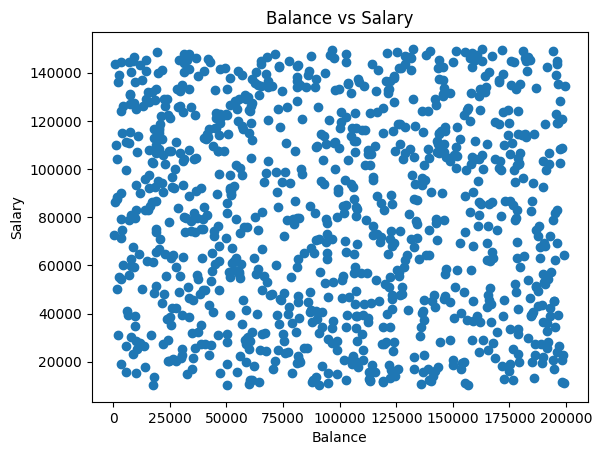

In [18]:
sample_df = df.sample(1000)
plt.scatter(sample_df["Balance"], sample_df["EstimatedSalary"])
plt.title("Balance vs Salary")
plt.xlabel("Balance")
plt.ylabel("Salary")
plt.show()



BOX PLOT

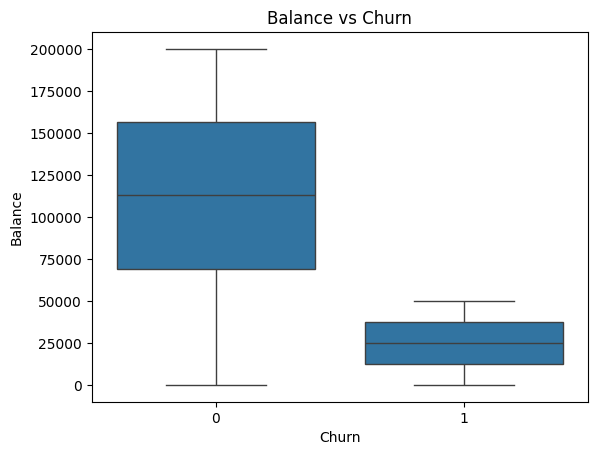

In [19]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.xlabel("Churn")
plt.ylabel("Balance")
plt.show()


HEAT MAP

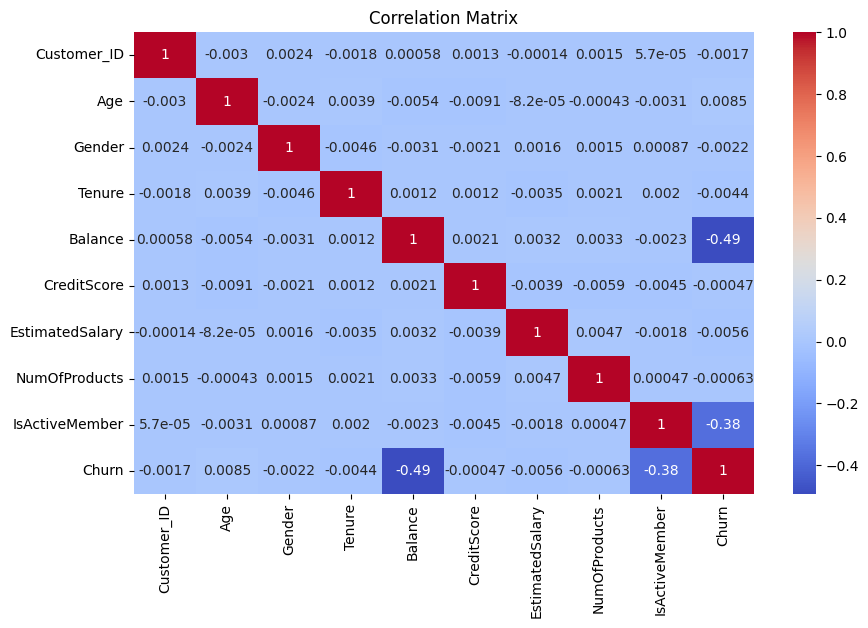

In [23]:

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [21]:
print("Average Balance (Churned):", df[df["Churn"]==1]["Balance"].mean())
print("Average Balance (Not Churned):", df[df["Churn"]==0]["Balance"].mean())
print("Inactive Members Churn Rate:")
print(df[df["IsActiveMember"]==0]["Churn"].mean())



Average Balance (Churned): 24961.34249380941
Average Balance (Not Churned): 110972.72541980543
Inactive Members Churn Rate:
0.24870867768595042
